## MAPE vs. Pseudo-MAPE

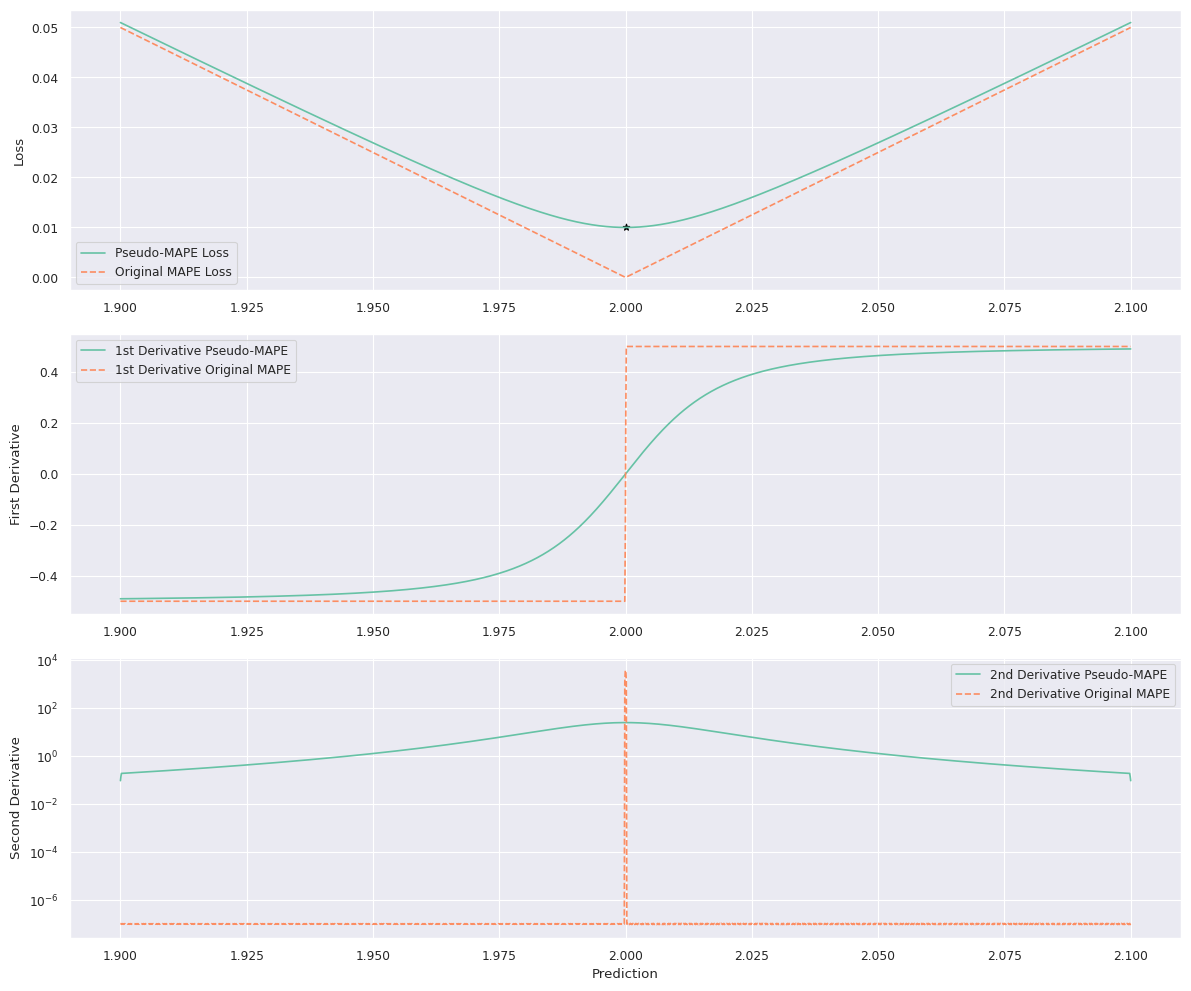

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("paper")
sns.set_palette("Set2")
sns.set_style("darkgrid")

DELTA = 1e-2
DELTA_SQURED = DELTA**2
GRID_PRESICION = 2_000
EPS = 1e-9


def pseudo_mape_loss(preds, y):
    eps = EPS
    y_safe = np.where(y == 0, eps, y)
    r = (preds - y) / y_safe
    return np.sqrt(r**2 + DELTA_SQURED)


def original_mape_loss(preds, y):
    eps = EPS
    y_safe = np.where(y == 0, eps, y)
    return np.abs(preds - y) / y_safe


y_true = 2.0
y_delta = 0.1
preds = np.linspace(y_true - y_delta, y_true + y_delta, GRID_PRESICION)
pseudo_loss = pseudo_mape_loss(preds, y_true)
orig_loss = original_mape_loss(preds, y_true)

dx = preds[1] - preds[0]
pseudo_first = np.gradient(pseudo_loss, dx)
orig_first = np.gradient(orig_loss, dx)
pseudo_second = np.gradient(pseudo_first, dx)
orig_second = np.gradient(orig_first, dx)

plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(preds, pseudo_loss, label="Pseudo-MAPE Loss")
plt.plot(preds, orig_loss, label="Original MAPE Loss", linestyle="--")
plt.scatter(x=y_true, y=DELTA, marker="*", c="black")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(preds, pseudo_first, label="1st Derivative Pseudo-MAPE")
plt.plot(preds, orig_first, label="1st Derivative Original MAPE", linestyle="--")
plt.ylabel("First Derivative")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(preds, 1e-7 + pseudo_second, label="2nd Derivative Pseudo-MAPE")
plt.plot(preds, 1e-7 + orig_second, label="2nd Derivative Original MAPE", linestyle="--")
plt.xlabel("Prediction")
plt.ylabel("Second Derivative")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()